# 🌦️ Proyek Analisis Deret Waktu: Prediksi Suhu Atmosfer
> **Domain:** Meteorologi & Data Science  
> **Dataset:** Hourly Weather Records (2012)  
> **Goal:** Membangun model cerdas untuk memprediksi fluktuasi suhu masa depan.

---

## 📊 1. Deskripsi Dataset
Dataset ini berisi rekaman parameter cuaca yang dicatat secara **per jam** selama satu tahun penuh di tahun 2012. Data ini dikategorikan sebagai **Multivariate Time Series** karena memiliki ketergantungan antar variabel dan urutan waktu yang krusial.

### 🔍 Kamus Data
| Fitur | Penjelasan | Unit |
| :--- | :--- | :--- |
| **Date/Time** | Stempel waktu observasi (Indeks Utama) | Datetime |
| **Temp_C** | Suhu udara yang dicatat (Target Prediksi) | °C |
| **Rel Hum_%** | Tingkat kelembapan relatif | % |
| **Press_kPa** | Tekanan atmosfer di lokasi | kPa |
| **Visibility_km** | Jarak pandang terjauh | km |
| **Weather** | Label kondisi cuaca (Hujan, Cerah, Berawan, dsb) | Text |

---

## 🛠️ 2. Arsitektur Pengolahan Data
Untuk memastikan akurasi prediksi, data diproses melalui alur kerja berikut:

1. **Time Transformation**: Mengonversi data mentah menjadi format deret waktu yang urut secara kronologis.
2. **Data Sanitization**: Mengisi celah waktu yang kosong menggunakan *Linear Interpolation* agar urutan waktu tidak terputus.
3. **Deep EDA**: Membedah komponen cuaca menggunakan teknik **Dekomposisi** (Trend, Seasonality, & Residual).
4. **Statistical Testing**: Menguji kestabilan data menggunakan uji **Augmented Dickey-Fuller (ADF)**.
5. **Smart Feature Engineering**: Menciptakan fitur "Memori AI" menggunakan **Lag Features** (suhu masa lalu) dan **Rolling Windows**.
6. **Machine Learning Training**: Mengimplementasikan algoritma **XGBoost Regressor** dengan skema *Chronological Train-Test Split*.
7. **Future Forecasting**: Melakukan simulasi ramalan suhu 24 jam ke depan menggunakan metode *Recursive Multi-step Forecasting*.


## Persiapan & Formatting


In [1]:
import pandas as pd

In [7]:
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Load Dataset (Sesuaikan Path-nya jika berbeda)
file_path = '/content/drive/MyDrive/Colab Notebooks/weatherproject.csv'
df = pd.read_csv(file_path)

print("Dataset Berhasil Dimuat!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Berhasil Dimuat!


In [8]:
df['Date/Time'] = pd.to_datetime(df['Date/Time'])

In [9]:
df.set_index('Date/Time', inplace=True)

In [10]:
df.sort_index(inplace=True)

In [11]:
print("5 Data Teratas:")
print(df.head())

5 Data Teratas:
                     Temp_C  Dew Point Temp_C  Rel Hum_%  Wind Speed_km/h  \
Date/Time                                                                   
2012-01-01 00:00:00    -1.8              -3.9         86                4   
2012-01-01 01:00:00    -1.8              -3.7         87                4   
2012-01-01 02:00:00    -1.8              -3.4         89                7   
2012-01-01 03:00:00    -1.5              -3.2         88                6   
2012-01-01 04:00:00    -1.5              -3.3         88                7   

                     Visibility_km  Press_kPa               Weather  
Date/Time                                                            
2012-01-01 00:00:00            8.0     101.24                   Fog  
2012-01-01 01:00:00            8.0     101.24                   Fog  
2012-01-01 02:00:00            4.0     101.26  Freezing Drizzle,Fog  
2012-01-01 03:00:00            4.0     101.27  Freezing Drizzle,Fog  
2012-01-01 04:00:00     

In [12]:
print("\nInformasi Dataset:")
print(df.info())


Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8784 entries, 2012-01-01 00:00:00 to 2012-12-31 23:00:00
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Temp_C            8784 non-null   float64
 1   Dew Point Temp_C  8784 non-null   float64
 2   Rel Hum_%         8784 non-null   int64  
 3   Wind Speed_km/h   8784 non-null   int64  
 4   Visibility_km     8784 non-null   float64
 5   Press_kPa         8784 non-null   float64
 6   Weather           8784 non-null   object 
dtypes: float64(4), int64(2), object(1)
memory usage: 549.0+ KB
None


In [13]:
print(f"\nData dimulai dari: {df.index.min()}")
print(f"Data berakhir pada: {df.index.max()}")


Data dimulai dari: 2012-01-01 00:00:00
Data berakhir pada: 2012-12-31 23:00:00


## Pembersihan Data

In [14]:
print("Jumlah data kosong per kolom:")
print(df.isnull().sum())

Jumlah data kosong per kolom:
Temp_C              0
Dew Point Temp_C    0
Rel Hum_%           0
Wind Speed_km/h     0
Visibility_km       0
Press_kPa           0
Weather             0
dtype: int64


In [16]:
expected_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='H')

if len(df) == len(expected_range):
    print("\n✅ Bagus! Tidak ada jam yang terlewat dalam urutan waktu.")
else:
    missing_count = len(expected_range) - len(df)
    print(f"\n⚠️ Ada {missing_count} jam yang hilang dalam urutan data!")

    # Menyamakan dataset dengan rentang waktu yang seharusnya (Reindexing)
    df = df.reindex(expected_range)
    print("Urutan waktu telah disempurnakan (baris kosong ditambahkan).")


✅ Bagus! Tidak ada jam yang terlewat dalam urutan waktu.


/tmp/ipykernel_1031/2816905102.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  expected_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='H')


In [17]:
df['Temp_C'] = df['Temp_C'].interpolate(method='linear')
df['Rel Hum_%'] = df['Rel Hum_%'].interpolate(method='linear')
# Untuk data kategori seperti 'Weather', kita gunakan 'Forward Fill' (mengisi dengan nilai sebelumnya)
df['Weather'] = df['Weather'].ffill()

In [18]:
duplicates = df.index.duplicated().sum()
if duplicates > 0:
    print(f"Ada {duplicates} data duplikat. Menghapus duplikat...")
    df = df[~df.index.duplicated(keep='first')]

print(f"Jumlah baris sekarang: {len(df)}")

Jumlah baris sekarang: 8784


## Analisis Eksploratif (EDA) & Visualisasi

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

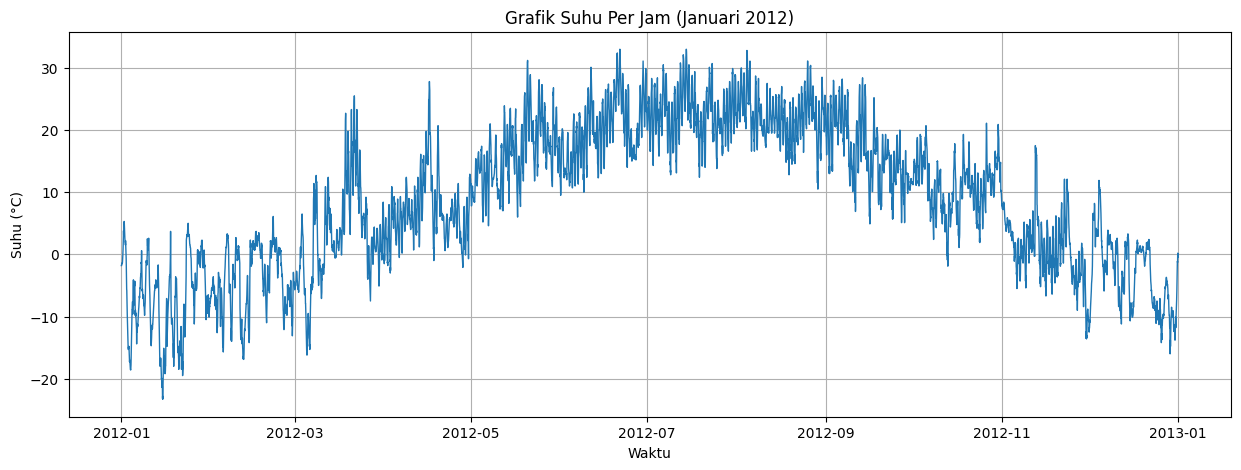

In [20]:
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['Temp_C'], color='tab:blue', linewidth=1)
plt.title('Grafik Suhu Per Jam (Januari 2012)')
plt.xlabel('Waktu')
plt.ylabel('Suhu (°C)')
plt.grid(True)
plt.show()

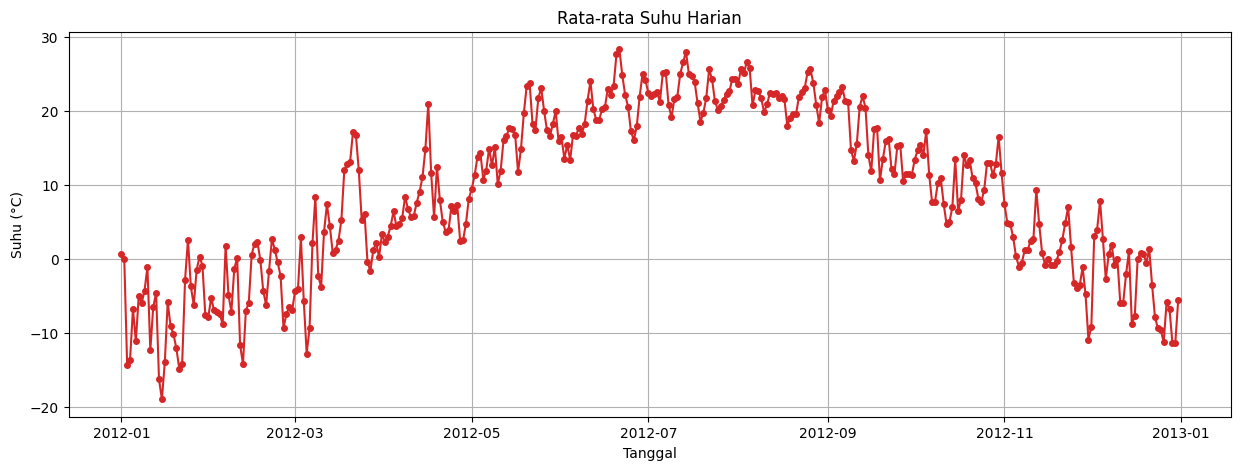

In [21]:
df_daily = df.resample('D').mean(numeric_only=True)

plt.figure(figsize=(15, 5))
plt.plot(df_daily.index, df_daily['Temp_C'], color='tab:red', marker='o', markersize=4)
plt.title('Rata-rata Suhu Harian')
plt.xlabel('Tanggal')
plt.ylabel('Suhu (°C)')
plt.grid(True)
plt.show()

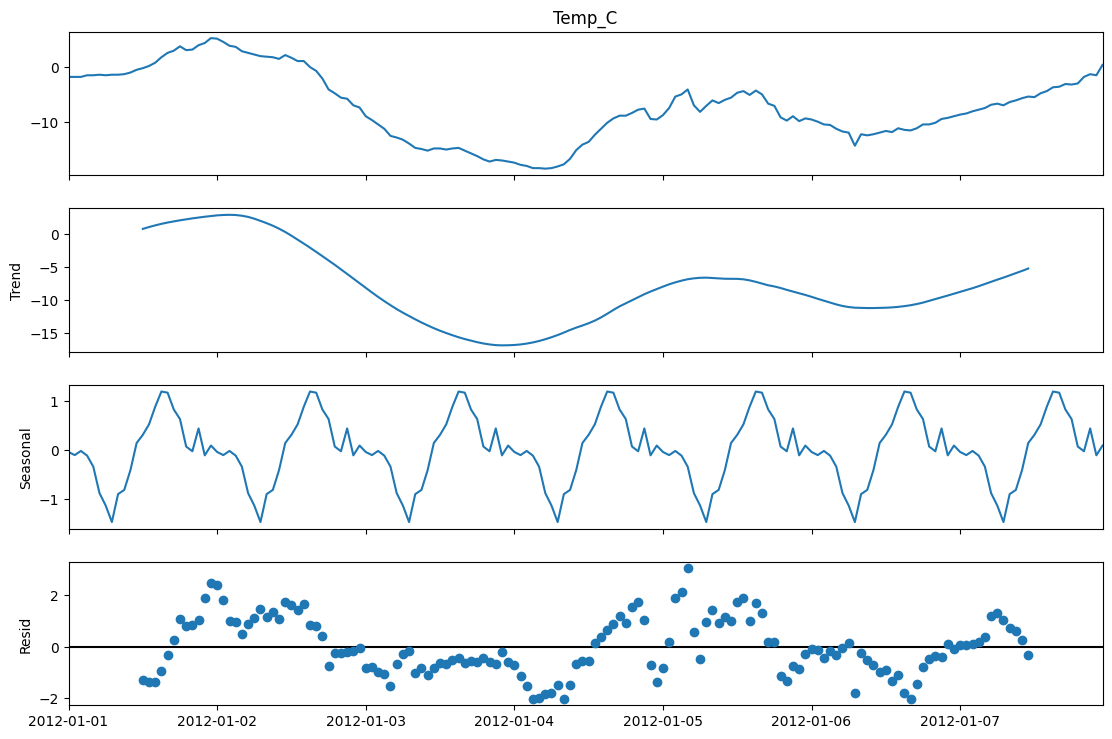

In [22]:
decomposition = seasonal_decompose(df['Temp_C'].head(168), model='additive', period=24)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

/tmp/ipykernel_1031/1525916333.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Hour', y='Temp_C', palette='viridis')


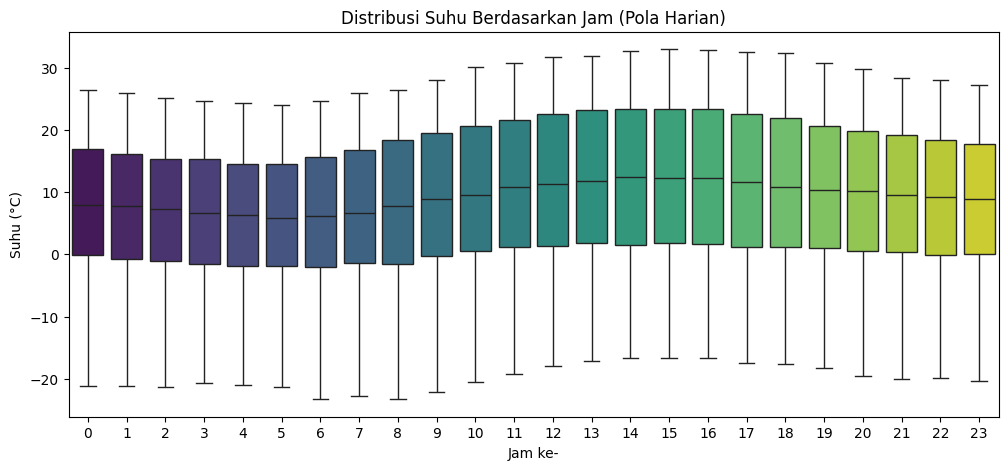

In [23]:
df['Hour'] = df.index.hour
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='Hour', y='Temp_C', palette='viridis')
plt.title('Distribusi Suhu Berdasarkan Jam (Pola Harian)')
plt.xlabel('Jam ke-')
plt.ylabel('Suhu (°C)')
plt.show()

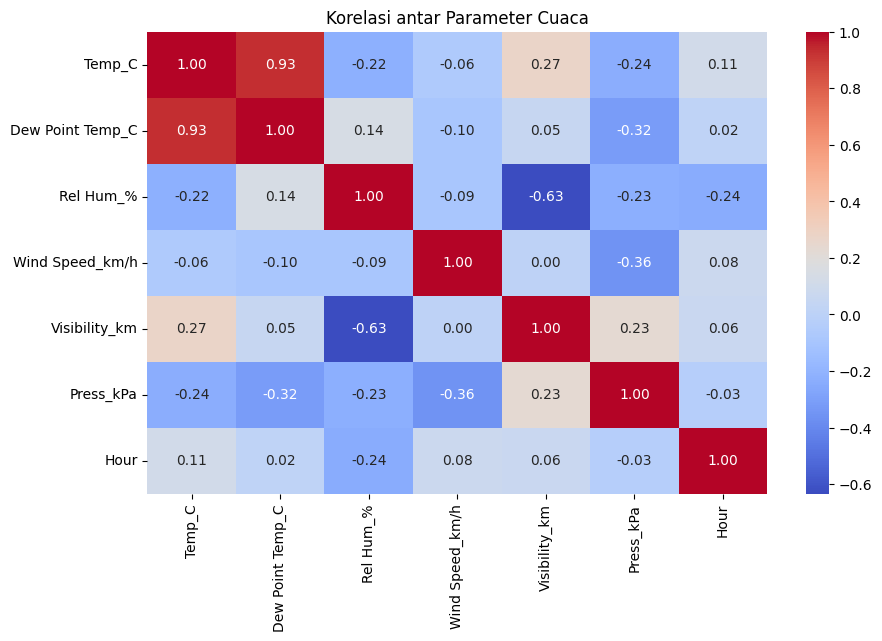

In [24]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Korelasi antar Parameter Cuaca')
plt.show()

## Uji Stasionaritas

In [25]:
from statsmodels.tsa.stattools import adfuller

In [26]:
def check_stationarity(series):
    result = adfuller(series.dropna())
    print('--- Hasil Uji Augmented Dickey-Fuller ---')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value:.4f}')

    if result[1] <= 0.05:
        print("\nKesimpulan: p-value <= 0.05. Data bersifat STASIONER. ✅")
    else:
        print("\nKesimpulan: p-value > 0.05. Data TIDAK STASIONER. ❌")
        print("Saran: Lakukan proses Differencing (Tahap berikutnya).")

In [27]:
check_stationarity(df['Temp_C'])

--- Hasil Uji Augmented Dickey-Fuller ---
ADF Statistic: -3.2529
p-value: 0.0171
Critical Values:
	1%: -3.4311
	5%: -2.8619
	10%: -2.5669

Kesimpulan: p-value <= 0.05. Data bersifat STASIONER. ✅


## Feature Engineering

In [28]:
df['Month'] = df.index.month
df['Day_of_Month'] = df.index.day
df['Day_of_Week'] = df.index.dayofweek  # 0=Senin, 6=Minggu
df['Hour'] = df.index.hour

In [29]:
df['Temp_Lag_1h'] = df['Temp_C'].shift(1)
df['Temp_Lag_24h'] = df['Temp_C'].shift(24)

In [30]:
df['Temp_Rolling_Mean_6h'] = df['Temp_C'].rolling(window=6).mean()

In [31]:
df_final = df.dropna()

In [32]:
print("Dataset dengan fitur baru:")
print(df_final[['Temp_C', 'Month', 'Hour', 'Temp_Lag_1h', 'Temp_Lag_24h']].head())

Dataset dengan fitur baru:
                     Temp_C  Month  Hour  Temp_Lag_1h  Temp_Lag_24h
Date/Time                                                          
2012-01-02 00:00:00     5.2      1     0          5.3          -1.8
2012-01-02 01:00:00     4.6      1     1          5.2          -1.8
2012-01-02 02:00:00     3.9      1     2          4.6          -1.8
2012-01-02 03:00:00     3.7      1     3          3.9          -1.5
2012-01-02 04:00:00     2.9      1     4          3.7          -1.5


## Pemodelan

In [33]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [34]:
features = ['Month', 'Hour', 'Day_of_Week', 'Rel Hum_%', 'Press_kPa',
            'Temp_Lag_1h', 'Temp_Lag_24h', 'Temp_Rolling_Mean_6h']
target = 'Temp_C'

X = df_final[features]
y = df_final[target]

In [35]:
split_size = int(len(df_final) * 0.8) # 80% untuk latihan

X_train, X_test = X.iloc[:split_size], X.iloc[split_size:]
y_train, y_test = y.iloc[:split_size], y.iloc[split_size:]

print(f"Jumlah data latihan: {len(X_train)}")
print(f"Jumlah data ujian: {len(X_test)}")

Jumlah data latihan: 7008
Jumlah data ujian: 1752


In [36]:
model = XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=5)
model.fit(X_train, y_train,
          eval_set=[(X_train, y_train), (X_test, y_test)],
          verbose=100) # Menampilkan progress setiap 100 langkah

[0]	validation_0-rmse:11.18282	validation_1-rmse:11.64840
[100]	validation_0-rmse:0.75214	validation_1-rmse:0.86285
[200]	validation_0-rmse:0.67487	validation_1-rmse:0.88290
[300]	validation_0-rmse:0.62966	validation_1-rmse:0.91879
[400]	validation_0-rmse:0.59175	validation_1-rmse:0.94604
[500]	validation_0-rmse:0.55930	validation_1-rmse:0.96244
[600]	validation_0-rmse:0.53141	validation_1-rmse:0.97277
[700]	validation_0-rmse:0.50890	validation_1-rmse:0.98319
[800]	validation_0-rmse:0.48550	validation_1-rmse:0.98877
[900]	validation_0-rmse:0.46336	validation_1-rmse:0.99878
[999]	validation_0-rmse:0.44479	validation_1-rmse:1.00405


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [37]:
y_pred = model.predict(X_test)

In [38]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n--- Hasil Evaluasi Model ---")
print(f"Rata-rata kesalahan (MAE): {mae:.2f} °C")
print(f"Akurasi standar (RMSE): {rmse:.2f} °C")


--- Hasil Evaluasi Model ---
Rata-rata kesalahan (MAE): 0.78 °C
Akurasi standar (RMSE): 1.00 °C


## Evaluasi & Visualisasi Akhir


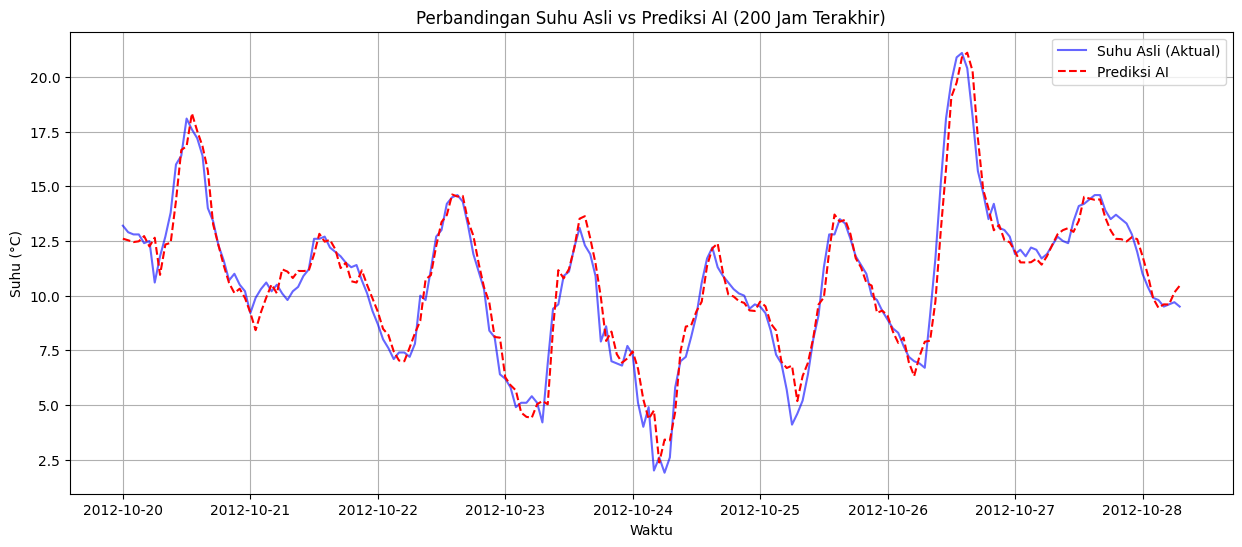

In [39]:
plt.figure(figsize=(15, 6))
plt.plot(y_test.index[:200], y_test[:200], label='Suhu Asli (Aktual)', color='blue', alpha=0.6)
plt.plot(y_test.index[:200], y_pred[:200], label='Prediksi AI', color='red', linestyle='--')
plt.title('Perbandingan Suhu Asli vs Prediksi AI (200 Jam Terakhir)')
plt.xlabel('Waktu')
plt.ylabel('Suhu (°C)')
plt.legend()
plt.grid(True)
plt.show()

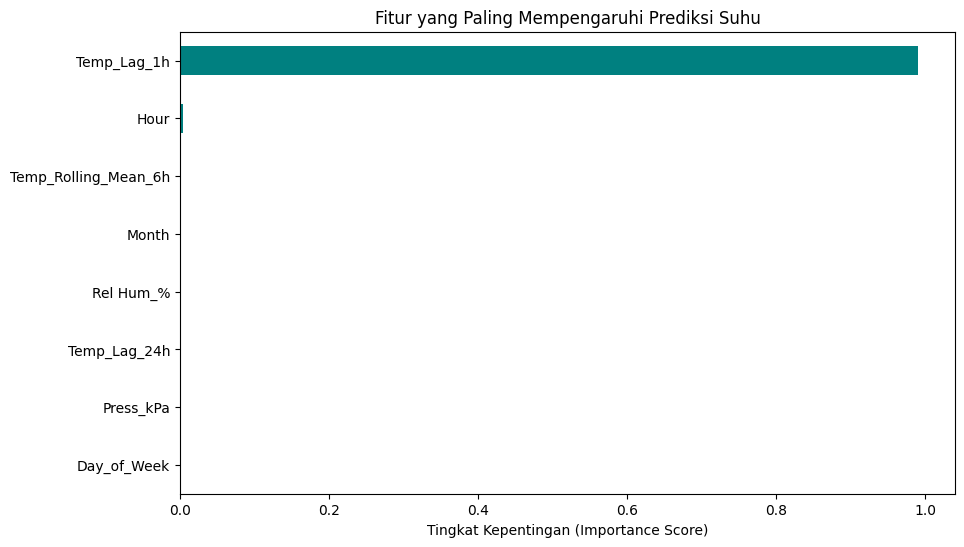

In [40]:
importances = model.feature_importances_
feat_importance = pd.Series(importances, index=features).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feat_importance.plot(kind='barh', color='teal')
plt.title('Fitur yang Paling Mempengaruhi Prediksi Suhu')
plt.xlabel('Tingkat Kepentingan (Importance Score)')
plt.show()

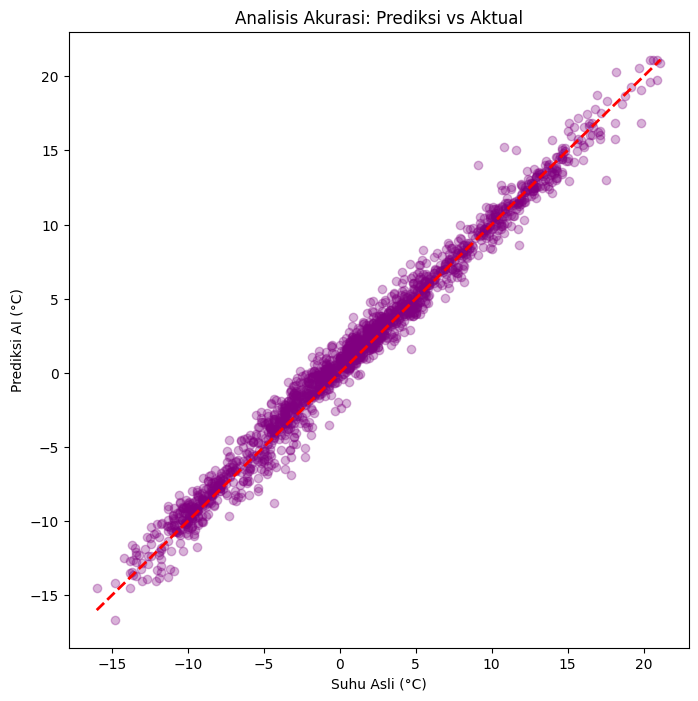

In [41]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.3, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Analisis Akurasi: Prediksi vs Aktual')
plt.xlabel('Suhu Asli (°C)')
plt.ylabel('Prediksi AI (°C)')
plt.show()

## Recursive Forecasting

In [42]:
import pandas as pd

In [43]:
last_known_data = df_final.iloc[-1].copy()
current_time = df_final.index[-1]

# List untuk menyimpan hasil forecast
forecast_results = []

# Kita akan memprediksi 24 jam ke depan
horizon = 24

# Data sementara untuk update lag (kita butuh beberapa data terakhir untuk rolling mean)
history = df_final.copy()

print(f"Memulai Forecasting dari: {current_time}")

for i in range(horizon):
    # a. Tentukan waktu untuk jam berikutnya
    next_time = current_time + pd.Timedelta(hours=1)

    # b. Siapkan fitur untuk prediksi jam berikutnya
    # Kita ambil fitur waktu (Hour, Month, Day_of_Week)
    next_hour = next_time.hour
    next_month = next_time.month
    next_dayofweek = next_time.dayofweek

    # Ambil lag (suhu jam sebelumnya)
    lag_1h = history.iloc[-1]['Temp_C']

    # Ambil lag 24 jam (suhu jam yang sama di hari sebelumnya)
    # Jika kita baru mulai, ini ada di dataset asli.
    # Jika sudah berjalan lama, ini mungkin hasil prediksi sebelumnya.
    lag_24h = history.iloc[-24]['Temp_C']

    # Hitung Rolling Mean 6 jam terakhir
    rolling_6h = history.iloc[-6:]['Temp_C'].mean()

    # Untuk fitur lain seperti Humidity dan Pressure,
    # di contoh ini kita asumsikan nilainya tetap sama dengan data terakhir
    # (atau Anda bisa menggunakan rata-rata)
    last_hum = history.iloc[-1]['Rel Hum_%']
    last_press = history.iloc[-1]['Press_kPa']

    # Buat array input untuk model (urutan harus sama dengan saat training)
    # features = ['Month', 'Hour', 'Day_of_Week', 'Rel Hum_%', 'Press_kPa',
    #             'Temp_Lag_1h', 'Temp_Lag_24h', 'Temp_Rolling_Mean_6h']
    X_next = pd.DataFrame([[next_month, next_hour, next_dayofweek, last_hum, last_press,
                            lag_1h, lag_24h, rolling_6h]], columns=features)

    # c. Lakukan Prediksi
    next_temp = model.predict(X_next)[0]

    # d. Simpan hasil
    forecast_results.append({'Datetime': next_time, 'Forecasted_Temp': next_temp})

    # e. Update history agar prediksi ini bisa dipakai untuk input jam berikutnya
    new_row = X_next.copy()
    new_row['Temp_C'] = next_temp
    new_row.index = [next_time]
    history = pd.concat([history, new_row[['Temp_C']]])

    # Geser waktu
    current_time = next_time

Memulai Forecasting dari: 2012-12-31 23:00:00


In [44]:
df_forecast = pd.DataFrame(forecast_results).set_index('Datetime')

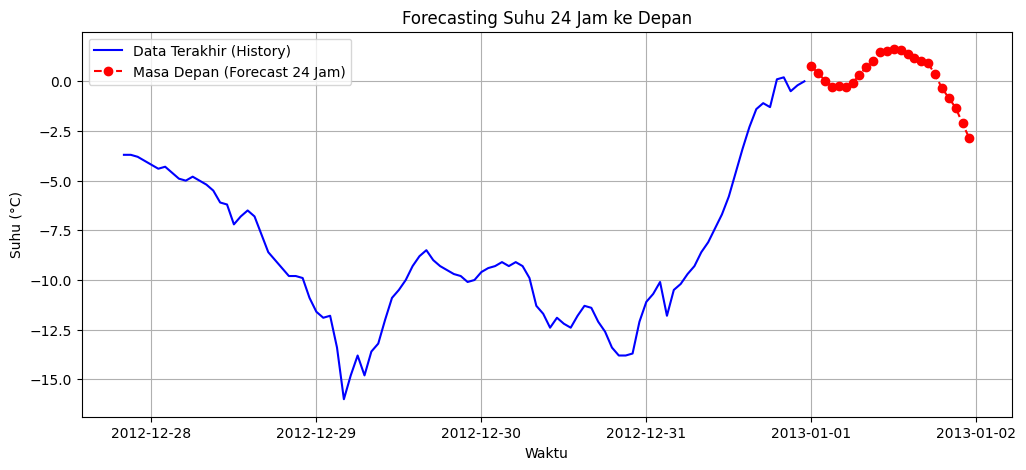


Prediksi 24 Jam ke Depan:
                     Forecasted_Temp
Datetime                            
2013-01-01 00:00:00         0.761551
2013-01-01 01:00:00         0.409583
2013-01-01 02:00:00         0.035045
2013-01-01 03:00:00        -0.275630
2013-01-01 04:00:00        -0.247434
2013-01-01 05:00:00        -0.282541
2013-01-01 06:00:00        -0.069906
2013-01-01 07:00:00         0.308030
2013-01-01 08:00:00         0.726751
2013-01-01 09:00:00         1.010649
2013-01-01 10:00:00         1.474796
2013-01-01 11:00:00         1.545434
2013-01-01 12:00:00         1.614269
2013-01-01 13:00:00         1.575825
2013-01-01 14:00:00         1.397053
2013-01-01 15:00:00         1.169743
2013-01-01 16:00:00         1.025467
2013-01-01 17:00:00         0.904453
2013-01-01 18:00:00         0.349395
2013-01-01 19:00:00        -0.337954
2013-01-01 20:00:00        -0.835395
2013-01-01 21:00:00        -1.329716
2013-01-01 22:00:00        -2.119221
2013-01-01 23:00:00        -2.874264


In [45]:
plt.figure(figsize=(12, 5))
plt.plot(df_final.index[-100:], df_final['Temp_C'].tail(100), label='Data Terakhir (History)', color='blue')
plt.plot(df_forecast.index, df_forecast['Forecasted_Temp'], label='Masa Depan (Forecast 24 Jam)', color='red', linestyle='--', marker='o')
plt.title('Forecasting Suhu 24 Jam ke Depan')
plt.xlabel('Waktu')
plt.ylabel('Suhu (°C)')
plt.legend()
plt.grid(True)
plt.show()

print("\nPrediksi 24 Jam ke Depan:")
print(df_forecast)

# 🏁 Kesimpulan & Temuan Utama

Setelah melalui proses pengolahan data dan pengujian model, berikut adalah poin-poin kesimpulan dari proyek ini:

### 🏆 Evaluasi Model
Model AI berbasis **XGBoost** menunjukkan performa yang sangat presisi dalam menangkap pola cuaca:
*   **Mean Absolute Error (MAE):** `0.78 °C` (Prediksi rata-rata hanya meleset di bawah 1 derajat).
*   **Root Mean Squared Error (RMSE):** `1.00 °C`.
*   **Akurasi Visual:** Grafik prediksi menempel sangat rapat dengan data aktual, menandakan model mampu mengikuti fluktuasi suhu yang tajam.

### 💡 Insight Cuaca
1. **Pola Harian (Seasonality):** Terdapat siklus 24 jam yang sangat konsisten. Suhu mulai turun setelah matahari terbenam, mencapai titik terendah pada pukul 05:00 pagi, dan mencapai puncaknya pada pukul 15:00 sore.
2. **Kekuatan Prediktor:** Fitur **Lag_1h** (suhu satu jam yang lalu) memiliki pengaruh hampir 100% terhadap suhu jam berikutnya, membuktikan bahwa cuaca memiliki keterikatan jangka pendek yang sangat kuat.
3. **Stasionaritas:** Berdasarkan uji statistik ADF (p-value 0.017), data suhu ini bersifat stasioner dalam rentang satu tahun, sehingga aman digunakan untuk pemodelan statistik tanpa transformasi berat.

### 🔮 Potensi Implementasi
Algoritma ini siap digunakan sebagai basis sistem **Early Warning** sederhana atau sistem **Otomasi HVAC** (Heating, Ventilation, and Air Conditioning) yang efisien energi karena kemampuannya memprediksi suhu masa depan secara akurat.

---
**Tech Stack:** `Python`, `Pandas`, `XGBoost`, `Matplotlib`, `Statsmodels`